In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [41]:
population = pd.read_csv("../data/population.csv")
pollution  = pd.read_csv("../data/global_air_pollution.csv")


In [82]:
merged.columns = merged.columns.str.replace("\n", " ", regex=False)
merged.columns = merged.columns.str.strip()

In [83]:
population.head(), pollution.head()


(       Country Density\n(P/Km2) Abbreviation Agricultural Land( %)  \
 0  Afghanistan               60           AF                58.10%   
 1      Albania              105           AL                43.10%   
 2      Algeria               18           DZ                17.40%   
 3      Andorra              164           AD                40.00%   
 4       Angola               26           AO                47.50%   
 
   Land Area(Km2) Armed Forces size  Birth Rate  Calling Code  \
 0        652,230           323,000       32.49          93.0   
 1         28,748             9,000       11.78         355.0   
 2      2,381,741           317,000       24.28         213.0   
 3            468               NaN        7.20         376.0   
 4      1,246,700           117,000       40.73         244.0   
 
   Capital/Major City Co2-Emissions  ... Out of pocket health expenditure  \
 0              Kabul         8,672  ...                           78.40%   
 1             Tirana     

In [84]:
population.info()
pollution.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    object 
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    object 
 4   Land Area(Km2)                             194 non-null    object 
 5   Armed Forces size                          171 non-null    object 
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    object 
 10  CPI                       

In [85]:
population.columns = population.columns.str.replace("\n", " ")
population.columns


Index(['Country', 'Density (P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='object')

In [86]:
#  Cleaning Function (Code cell)
pop = population.copy()

def clean_numeric(col):
    return (
        col.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
    )

cols_to_clean = [
    "Density (P/Km2)",
    "Agricultural Land( %)",
    "Land Area(Km2)",
    "Co2-Emissions",
    "GDP",
    "Population"
]

for col in cols_to_clean:
    pop[col] = pd.to_numeric(clean_numeric(pop[col]), errors="coerce")


In [87]:
pop.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density (P/Km2)                            195 non-null    int64  
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    float64
 4   Land Area(Km2)                             194 non-null    float64
 5   Armed Forces size                          171 non-null    object 
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    float64
 10  CPI                       

In [88]:
pop.describe()


,Density (P/Km2),Agricultural Land( %),Land Area(Km2),Birth Rate,Calling Code,Co2-Emissions,Fertility Rate,GDP,Infant mortality,Life expectancy,Maternal mortality ratio,Physicians per thousand,Population,Latitude,Longitude
count,195.000000,188.000000,1.940000e+02,189.000000,194.000000,1.880000e+02,188.000000,0.0,189.000000,187.000000,181.000000,188.000000,1.940000e+02,194.000000,194.000000
mean,356.764103,39.117553,6.896244e+05,20.214974,360.546392,1.777992e+05,2.698138,NaN,21.332804,72.279679,160.392265,1.839840,3.938116e+07,19.092351,20.232434
std,1982.888967,21.783052,1.921609e+06,9.945774,323.236419,8.387903e+05,1.282267,NaN,19.548058,7.483661,233.502024,1.684261,1.450924e+08,23.961779,66.716110
min,2.000000,0.600000,0.000000e+00,5.900000,1.000000,1.100000e+01,0.980000,NaN,1.400000,52.800000,2.000000,0.010000,8.360000e+02,-40.900557,-175.198242
25%,35.500000,21.700000,2.382825e+04,11.300000,82.500000,2.304250e+03,1.705000,NaN,6.000000,67.000000,13.000000,0.332500,1.962678e+06,4.544175,-7.941496
50%,89.000000,39.600000,1.195110e+05,17.950000,255.500000,1.230300e+04,2.245000,NaN,14.000000,73.200000,53.000000,1.460000,8.826588e+06,17.273849,20.972652
75%,216.500000,55.375000,5.242560e+05,28.750000,506.750000,6.388425e+04,3.597500,NaN,32.700000,77.500000,186.000000,2.935000,2.858549e+07,40.124603,48.281523
max,26337.000000,82.600000,1.709824e+07,46.080000,1876.000000,9.893038e+06,6.910000,NaN,84.500000,85.400000,1150.000000,8.420000,1.397715e+09,64.963051,178.065032


In [89]:
pollution.describe()


,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


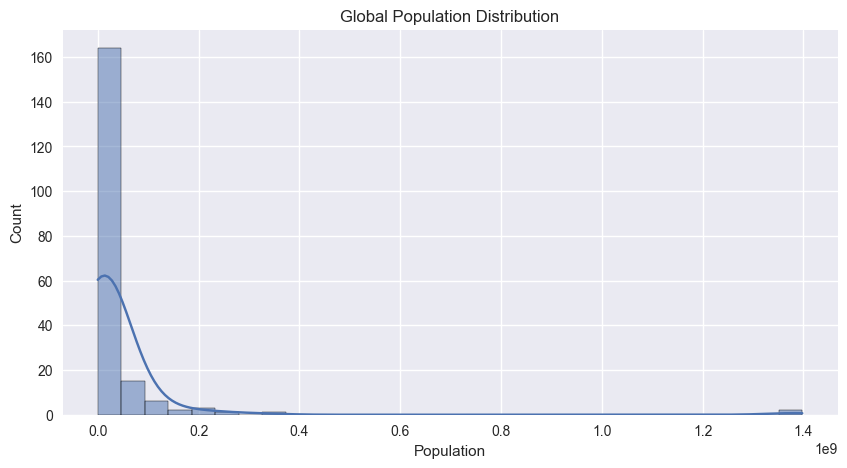

In [90]:
# First EDA Visuals
plt.figure(figsize=(10,5))
sns.histplot(pop["Population"], bins=30, kde=True)
plt.title("Global Population Distribution")
plt.show()


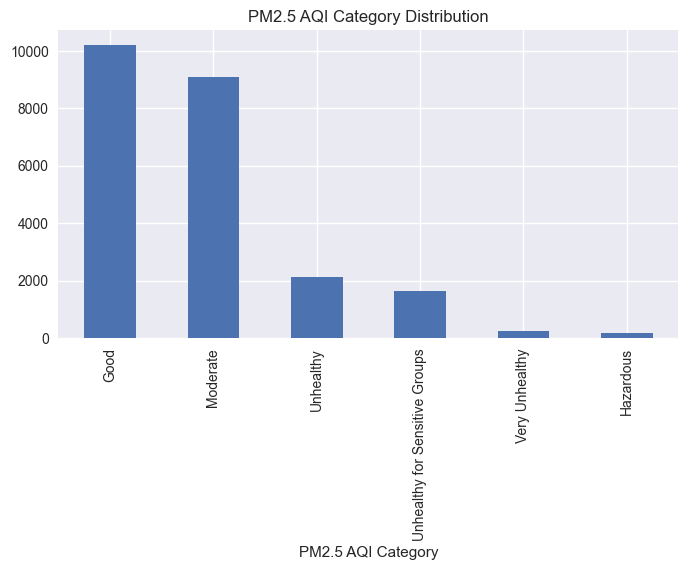

In [91]:
# AQI Category Distribution
pollution["PM2.5 AQI Category"].value_counts().plot(
    kind="bar", figsize=(8,4), title="PM2.5 AQI Category Distribution"
)

plt.show()

## 🔍 Initial Insights
- Population is heavily skewed toward a few highly populated countries
- Majority of AQI values fall into moderate to unhealthy categories
- Environmental stress is unevenly distributed across regions


## 🌫️ Pollution Severity by Country
Analyzing which countries experience the highest air pollution based on PM2.5 AQI values.


In [92]:
pollution.columns = pollution.columns.str.strip()
pollution.columns


Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category'],
      dtype='object')

In [93]:
country_pollution = (
    pollution.groupby("Country")["PM2.5 AQI Value"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

country_pollution


Country
Republic of Korea       415.000000
Bahrain                 188.000000
Mauritania              179.000000
Pakistan                173.110749
Aruba                   163.000000
Kuwait                  162.000000
United Arab Emirates    152.666667
Senegal                 152.424242
India                   149.463023
Saudi Arabia            149.285714
Qatar                   147.500000
Gambia                  147.000000
Yemen                   144.571429
Guinea-Bissau           138.750000
Oman                    134.833333
Name: PM2.5 AQI Value, dtype: float64

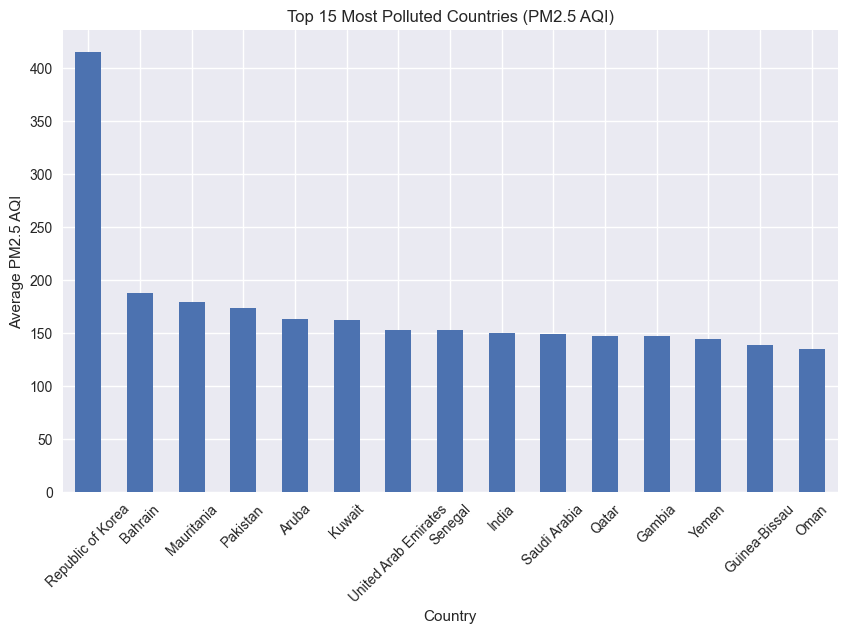

In [94]:
plt.figure(figsize=(10,6))
country_pollution.plot(kind="bar")
plt.title("Top 15 Most Polluted Countries (PM2.5 AQI)")
plt.ylabel("Average PM2.5 AQI")
plt.xticks(rotation=45)
plt.show()


In [95]:
country_pollution = (
    pollution.groupby("Country")["PM2.5 AQI Value"]
    .mean()
    .sort_values(ascending=False)
)

country_pollution_df = country_pollution.reset_index()
country_pollution_df.columns = ["Country", "Avg_PM25_AQI"]

In [96]:
merged = pd.merge(
    pop,
    country_pollution_df,
    on="Country",
    how="inner"
)

merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 36 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    153 non-null    object 
 1   Density (P/Km2)                            153 non-null    int64  
 2   Abbreviation                               152 non-null    object 
 3   Agricultural Land( %)                      151 non-null    float64
 4   Land Area(Km2)                             153 non-null    float64
 5   Armed Forces size                          145 non-null    object 
 6   Birth Rate                                 153 non-null    float64
 7   Calling Code                               153 non-null    float64
 8   Capital/Major City                         151 non-null    object 
 9   Co2-Emissions                              152 non-null    float64
 10  CPI                       

In [97]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 36 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    153 non-null    object 
 1   Density (P/Km2)                            153 non-null    int64  
 2   Abbreviation                               152 non-null    object 
 3   Agricultural Land( %)                      151 non-null    float64
 4   Land Area(Km2)                             153 non-null    float64
 5   Armed Forces size                          145 non-null    object 
 6   Birth Rate                                 153 non-null    float64
 7   Calling Code                               153 non-null    float64
 8   Capital/Major City                         151 non-null    object 
 9   Co2-Emissions                              152 non-null    float64
 10  CPI                       

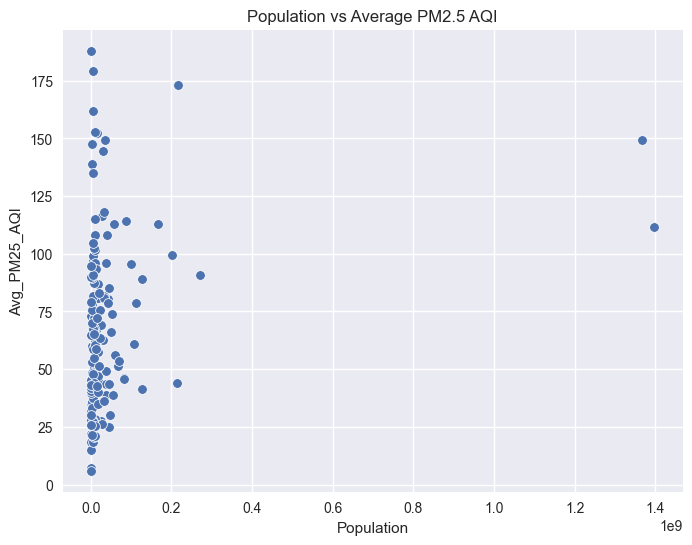

In [98]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged,
    x="Population",
    y="Avg_PM25_AQI"
)

plt.title("Population vs Average PM2.5 AQI")
plt.show()

In [102]:
merged["Population"].dtype

dtype('float64')

In [104]:
merged.columns

Index(['Country', 'Density (P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude', 'Avg_PM25_AQI'],
      dtype='object')

In [105]:
merged["Population"] = (
    merged["Population"]
    .str.replace(",", "", regex=False)
    .astype(float)
)

AttributeError: Can only use .str accessor with string values!

In [ ]:
merged[["Population", "Avg_PM25_AQI"]].corr()

,Population,Avg_PM25_AQI
Population,1.000000,0.240591
Avg_PM25_AQI,0.240591,1.000000


## 📈 Population vs Air Pollution Insight

There is a weak-to-moderate positive correlation (r ≈ 0.24)
between population size and average PM2.5 AQI levels.

This suggests that countries with larger populations
tend to experience higher pollution levels, but population
alone does not strongly determine air quality.

Other factors such as:
- Industrial activity
- Energy consumption
- Urban density
- Environmental policy
likely play a significant role.

In [ ]:
merged.columns

Index(['Country', 'Density\n(P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude', 'Avg_PM25_AQI'],
      dtype='object')

In [ ]:
# Density vs Pollution

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged,
    x="Density (P/Km2)",
    y="Avg_PM25_AQI"
)

plt.title("Population Density vs PM2.5 AQI")
plt.show()


ValueError: Could not interpret value `Density (P/Km2)` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [ ]:
merged[["Density (P/Km2)", "Avg_PM25_AQI"]].corr()

KeyError: "['Density (P/Km2)'] not in index"

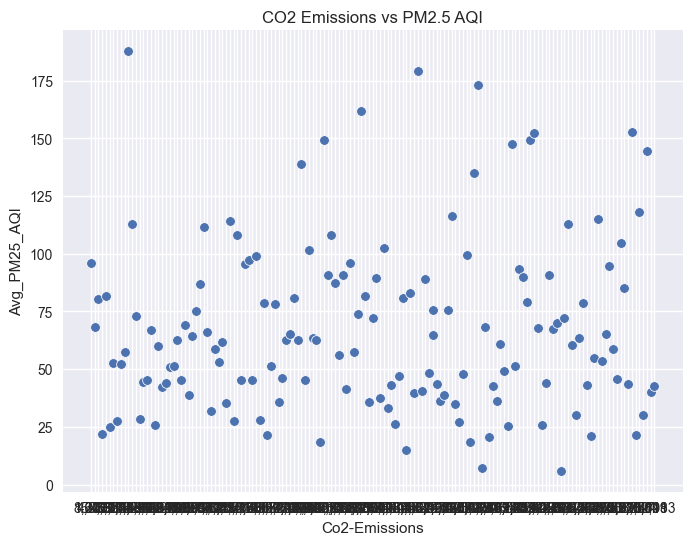

In [ ]:
# CO2 vs PM2.5
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged,
    x="Co2-Emissions",
    y="Avg_PM25_AQI"
)

plt.title("CO2 Emissions vs PM2.5 AQI")
plt.show()

In [ ]:
merged[["Co2-Emissions", "Avg_PM25_AQI"]].corr()

ValueError: could not convert string to float: '8,672'

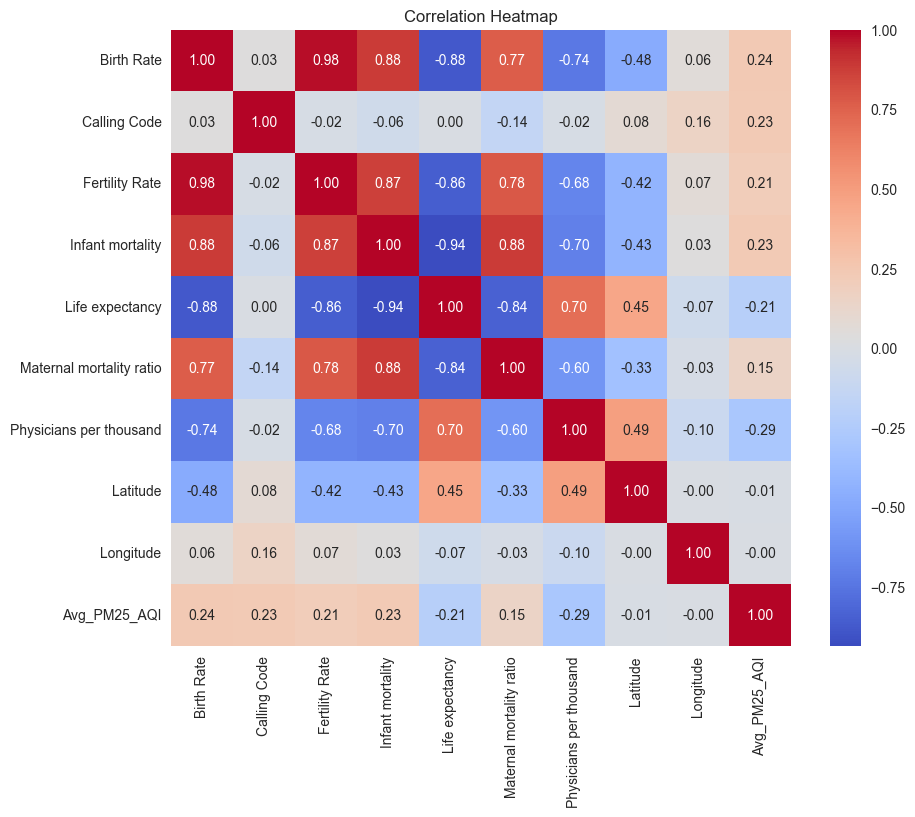

In [ ]:
# Correlation Heatmap (All Variables)
plt.figure(figsize=(10,8))

sns.heatmap(
    merged.select_dtypes(include=["float64", "int64"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

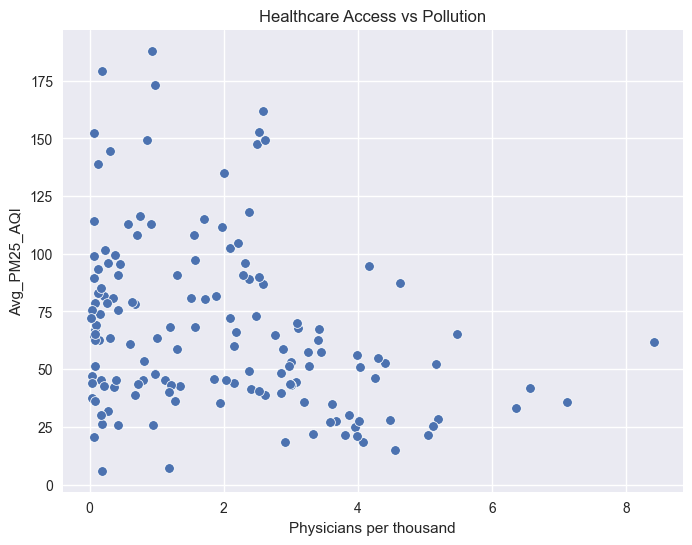

In [ ]:
# Development vs Pollution Analysis
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged,
    x="Physicians per thousand",
    y="Avg_PM25_AQI"
)

plt.title("Healthcare Access vs Pollution")
plt.show()

In [ ]:
merged[["Physicians per thousand", "Avg_PM25_AQI"]].corr()

,Physicians per thousand,Avg_PM25_AQI
Physicians per thousand,1.000000,-0.286664
Avg_PM25_AQI,-0.286664,1.000000


In [ ]:
features = merged[
    [
        "Avg_PM25_AQI",
        "Physicians per thousand",
        "Infant mortality",
        "Life expectancy",
        "Co2-Emissions"
    ]
].dropna()

features.head()

,Avg_PM25_AQI,Physicians per thousand,Infant mortality,Life expectancy,Co2-Emissions
0,95.918367,0.28,47.9,64.5,"8,672"
1,68.093750,1.20,7.8,78.5,"4,536"
2,80.250000,1.72,20.1,76.7,"150,006"
4,81.925926,0.21,51.6,60.8,"34,693"
5,24.867647,3.96,8.8,76.5,"201,348"


In [ ]:
# Standardize Data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

ValueError: could not convert string to float: '8,672'

In [ ]:
# KMeans Clustering

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

features["Cluster"] = clusters
features.head()

,Avg_PM25_AQI,Physicians per thousand,Infant mortality,Life expectancy,Co2-Emissions,Cluster
0,95.918367,0.28,47.9,64.5,"8,672",0
1,68.093750,1.20,7.8,78.5,"4,536",1
2,80.250000,1.72,20.1,76.7,"150,006",1
4,81.925926,0.21,51.6,60.8,"34,693",0
5,24.867647,3.96,8.8,76.5,"201,348",1


In [ ]:
# KMeans Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

features["Cluster"] = clusters
features.head()

,Avg_PM25_AQI,Physicians per thousand,Infant mortality,Life expectancy,Co2-Emissions,Cluster
0,95.918367,0.28,47.9,64.5,"8,672",0
1,68.093750,1.20,7.8,78.5,"4,536",1
2,80.250000,1.72,20.1,76.7,"150,006",1
4,81.925926,0.21,51.6,60.8,"34,693",0
5,24.867647,3.96,8.8,76.5,"201,348",1


In [ ]:
features.groupby("Cluster").mean()

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
# Add Cluster Label Meaning

cluster_map = {
    0: "High Risk (Low Health Infra)",
    1: "Developed & Low Pollution",
    2: "Industrial High Emission"
}

features["Cluster_Label"] = features["Cluster"].map(cluster_map)

In [ ]:
features.groupby("Cluster_Label").size()

KeyError: 'Cluster_Label'